In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/Colab Notebooks/IIS/archive.zip" -d ./fer2013


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 設定裝置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print("Using device:", device)

# 資料路徑
train_dir = "./fer2013/train"  # 原 train 資料
test_dir = "./fer2013/test"    # test 資料

# 資料轉換
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 載入完整 train 資料集
full_dataset = datasets.ImageFolder(train_dir, transform=transform)
num_total = len(full_dataset)
num_train = int(0.9 * num_total)
num_val = num_total - num_train
batch_size = 128
train_dataset, val_dataset = random_split(full_dataset, [num_train, num_val])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 載入 test 資料集
test_dataset = datasets.ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 建立 ResNet18
model = models.resnet18(pretrained=False)
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Loss 與 optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print(len(val_loader))

Using device: cuda
23


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# -------------------------
# 參數設定
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
num_epochs = 5
learning_rate = 1e-2
num_classes = 7  # FER2013 有 7 個表情

# -------------------------
# 資料預處理
# -------------------------
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # ResNet需要3通道
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

train_dataset = datasets.ImageFolder(root="./fer2013/train", transform=transform)
test_dataset = datasets.ImageFolder(root="./fer2013/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

-------------------------
模型
-------------------------
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# # -------------------------
# # 訓練與測試
# # -------------------------
train_logs = []  # 紀錄每個iteration
test_logs = []   # 紀錄每個epoch

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # 計算每個batch的accuracy
        _, preds = torch.max(outputs, 1)
        batch_corrects = torch.sum(preds == labels).item()
        batch_acc = batch_corrects / labels.size(0)

        # 紀錄每個iteration
        train_logs.append({
            'epoch': epoch+1,
            'iteration': i+1,
            'loss': loss.item(),
            'acc': batch_acc
        })

        if (i+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Iter [{i+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f}, Acc: {batch_acc:.4f}")

    # -------------------------
    # 每個epoch做一次測試
    # -------------------------
    model.eval()
    test_loss = 0.0
    test_corrects = 0
    total_test_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * labels.size(0)
            _, preds = torch.max(outputs, 1)
            test_corrects += torch.sum(preds == labels).item()
            total_test_samples += labels.size(0)

    epoch_test_loss = test_loss / total_test_samples
    epoch_test_acc = test_corrects / total_test_samples

    test_logs.append({
        'epoch': epoch+1,
        'loss': epoch_test_loss,
        'acc': epoch_test_acc
    })

    print(f"--- Epoch [{epoch+1}/{num_epochs}] Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc:.4f} ---")

# -------------------------
# 保存log
# -------------------------
import pandas as pd

pd.DataFrame(train_logs).to_csv("train_logs2.csv", index=False)
pd.DataFrame(test_logs).to_csv("test_logs2.csv", index=False)

print("訓練完成，log 已儲存成 CSV。")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1/5], Iter [10/449], Loss: 0.8892, Acc: 0.6406
Epoch [1/5], Iter [20/449], Loss: 1.1989, Acc: 0.4688
Epoch [1/5], Iter [30/449], Loss: 1.0323, Acc: 0.6406
Epoch [1/5], Iter [40/449], Loss: 1.0088, Acc: 0.6250
Epoch [1/5], Iter [50/449], Loss: 0.9855, Acc: 0.5625
Epoch [1/5], Iter [60/449], Loss: 0.9980, Acc: 0.5781
Epoch [1/5], Iter [70/449], Loss: 1.0901, Acc: 0.5469
Epoch [1/5], Iter [80/449], Loss: 1.1464, Acc: 0.5312
Epoch [1/5], Iter [90/449], Loss: 1.1435, Acc: 0.5469
Epoch [1/5], Iter [100/449], Loss: 1.1077, Acc: 0.5156
Epoch [1/5], Iter [110/449], Loss: 0.9300, Acc: 0.6719
Epoch [1/5], Iter [120/449], Loss: 1.0302, Acc: 0.6719
Epoch [1/5], Iter [130/449], Loss: 1.0673, Acc: 0.6406
Epoch [1/5], Iter [140/449], Loss: 0.9285, Acc: 0.7031
Epoch [1/5], Iter [150/449], Loss: 1.0547, Acc: 0.6094
Epoch [1/5], Iter [160/449], Loss: 1.2017, Acc: 0.5781
Epoch [1/5], Iter [170/449], Loss: 1.1222, Acc: 0.5938
Epoch [1/5], Iter [180/449], Loss: 1.1863, Acc: 0.5469
Epoch [1/5], Iter [

KeyboardInterrupt: 

0    0.156250
1    0.258150
2    0.383951
3    0.480635
4    0.516578
5    0.550432
6    0.560000
7    0.560000
Name: acc, dtype: float64


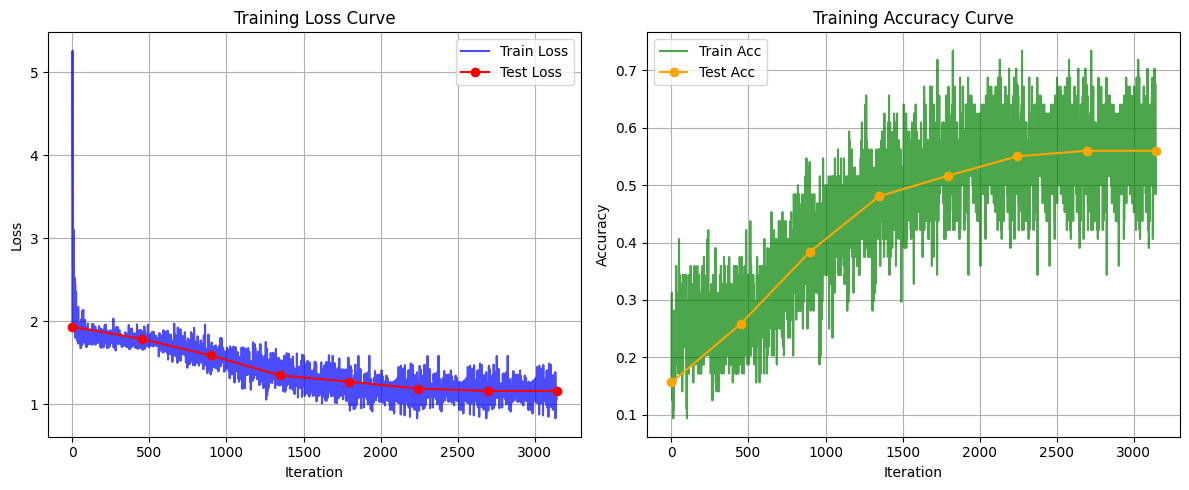

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# # 讀取 log
train_logs = pd.read_csv("train_logs.csv")
test_logs = pd.read_csv("test_logs.csv")

loss_array = train_logs['loss'].values
acc_array = train_logs['acc'].values

# -------------------------
# 畫 Training Loss
# -------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_logs['loss'], label='Train Loss', color='blue', alpha=0.7)
plt.plot(test_logs['epoch']*449, test_logs['loss'], label='Test Loss', marker='o', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.legend()


# -------------------------
# 畫 Training Accuracy
# -------------------------
plt.subplot(1,2,2)
plt.plot(train_logs['acc'], label='Train Acc', color='green', alpha=0.7)
plt.plot((test_logs['epoch'])*449, test_logs['acc'], label='Test Acc', marker='o', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Curve')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np

# -------------------------
# 模型推論
# -------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


NameError: name 'classes' is not defined

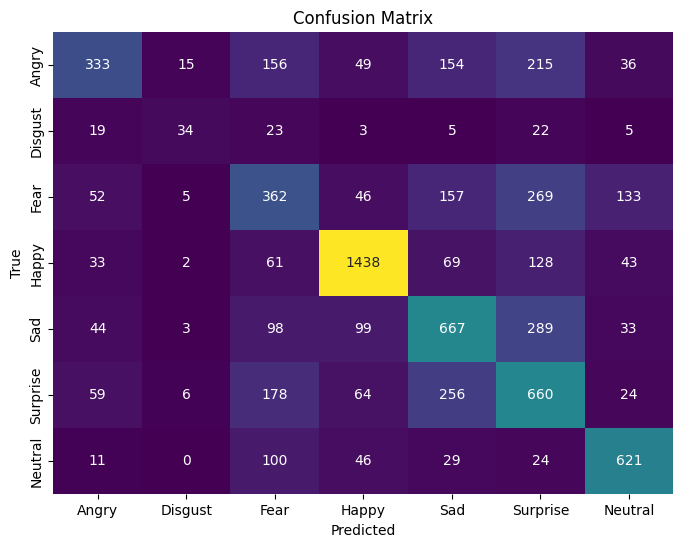

Weighted F1-score: 0.5713


In [ ]:
classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
cm = confusion_matrix(all_labels, all_preds)
# sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=classes, yticklabels=classes, cbar=False)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=classes, yticklabels=classes, cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# 計算 F1-score
# -------------------------
f1 = f1_score(all_labels, all_preds, average='weighted')  # weighted 針對各類別樣本數不同
print(f"Weighted F1-score: {f1:.4f}")